# Info

- Objetivo: Código utilizado para treinar e carregar modelos MGGP.

# Imports

In [1]:
import numpy as np 
import pandas as pd
from mggp import MGGP
from sklearn.preprocessing import StandardScaler
import os
import re 
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import butter,filtfilt
# from sklearn.preprocessing import MinMaxScaler
import pickle
from tensorflow.keras import backend as K
# from tensorflow.keras.models import load_model
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
import keras
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, mean_squared_error

# Functions

In [2]:
def sign(X1, X2):
    return np.sign(X1 - X2)

def sub(X1, X2):
    return X1 - X2


def mcase_free_run_terms(u, y_init):
    u = np.asarray(u)
    N = len(u)

    y_pred = np.zeros(N)

    # número de termos = 11 (theta[0] até theta[10])
    terms = np.zeros((11, N))

    # inicialização
    y_pred[:10] = y_init[:10].reshape(-1)

    theta = [
        -6.449701883681769e-14,
        0.300742221603808,
        1.157059550460019,
        0.03974769250889043,
        -0.09372108147028588,
        1.0571898587117923,
        -0.05383488830604312,
        0.05397338896144662,
        -3.271439267907053,
        1.0571898587352877,
        0.7530926667022311
    ]

    for k in range(10, N):
              

        # cada termo separado
        terms[0, k]  = theta[0]
        terms[1, k]  = theta[1] * y_pred[k-3]
        terms[2, k]  = theta[2] * u[k-11]
        terms[3, k]  = theta[3] * sub(u[k-6], u[k-7])
        terms[4, k]  = theta[4] * sub(u[k-10], u[k-4])
        terms[5, k]  = theta[5] * u[k-1]
        terms[6, k]  = theta[6] * y_pred[k-11]
        terms[7, k]  = theta[7] * sign(u[k-2], u[k-5])
        terms[8, k]  = theta[8] * u[k-7]
        terms[9, k]  = theta[9] * u[k-1]
        terms[10, k] = theta[10] * y_pred[k-1]

        # soma total (modelo original)
        y_pred[k] = np.sum(terms[:, k])

    return y_pred[10:], terms[:, 10:]


In [3]:
def insert_constant_segments(signal, n_const=3, len_const=100, seed=42):
    """
    Insere segmentos constantes em posições aleatórias, mas reprodutíveis.

    Parâmetros:
    - signal: array (N,1)
    - n_const: número de segmentos constantes
    - len_const: tamanho de cada segmento
    - seed: semente do gerador aleatório

    Retorna:
    - novo sinal com trechos constantes inseridos
    """
    
    rng = np.random.default_rng(seed)
    
    signal = signal.flatten()
    N = len(signal)

    # posições aleatórias reprodutíveis
    positions = np.sort(rng.choice(np.arange(1, N-1), n_const, replace=False))

    new_signal = []
    last_idx = 0

    for pos in positions:
        new_signal.extend(signal[last_idx:pos])

        const_value = signal[pos]
        new_signal.extend([const_value] * len_const)

        last_idx = pos

    new_signal.extend(signal[last_idx:])

    return np.array(new_signal).reshape(-1, 1)

In [4]:
def sign(X1, X2):
    return np.sign(X1 - X2)

def sub(X1, X2):
    return X1 - X2

import numpy as np

def sign(X1, X2):
    return np.sign(X1 - X2)

def sub(X1, X2):
    return X1 - X2


def mcase(u, y_init):
    u = np.asarray(u)
    N = len(u)

    y_pred = np.zeros(N)

    # inicialização com histórico real
    y_pred[:10] = y_init[:10].reshape(-1)

    theta = [
        -6.449701883681769e-14,
        0.300742221603808,
        1.157059550460019,
        0.03974769250889043,
        -0.09372108147028588,
        1.0571898587117923,
        -0.05383488830604312,
        0.05397338896144662,
        -3.271439267907053,
        1.0571898587352877,
        0.7530926667022311
    ]

    for k in range(10, N):

        y_pred[k] = (
            theta[0] +
            theta[1] * y_pred[k-3] +
            theta[2] * u[k-11] +
            theta[3] * sub(u[k-6], u[k-7]) +
            theta[4] * sub(u[k-10], u[k-4]) +
            theta[5] * u[k-1] +
            theta[6] * y_pred[k-11] +
            theta[7] * sign(u[k-2], u[k-5]) +
            theta[8] * u[k-7] +
            theta[9] * u[k-1] +
            theta[10] * y_pred[k-1]  
        )

    return y_pred


def mcaseOSA(u, y):
    u = np.asarray(u)
    y = np.asarray(y)

    N = len(u)
    y_pred = np.zeros(N)
    
    y_pred[:10] = y[:10].reshape(-1)
    theta = [
        -6.449701883681769e-14,
        0.300742221603808,
        1.157059550460019,
        0.03974769250889043,
        -0.09372108147028588,
        1.0571898587117923,
        -0.05383488830604312,
        0.05397338896144662,
        -3.271439267907053,
        1.0571898587352877,
        0.7530926667022311
    ]

    for k in range(10, N):

        # y_pred[k] = (
        #     theta[0] +  # bias
        #     theta[1] * y[k-2] +
        #     theta[2] * u[k-10] +
        #     theta[3] * sub(u[k-5], u[k-6]) +
        #     theta[4] * sub(u[k-9], u[k-3]) +
        #     theta[5] * u[k] +
        #     theta[6] * y[k-10] +
        #     theta[7] * sign(u[k-1], u[k-4]) +
        #     theta[8] * u[k-6] +
        #     theta[9] * u[k] +
        #     theta[10] * y[k]
        # )
        y_pred[k] = (
            theta[0] +  # bias
            theta[1] * y[k-3] +
            theta[2] * u[k-11] +
            theta[3] * sub(u[k-6], u[k-7]) +
            theta[4] * sub(u[k-10], u[k-4]) +
            theta[5] * u[k-1] +
            theta[6] * y[k-11] +
            theta[7] * sign(u[k-2], u[k-5]) +
            theta[8] * u[k-7] +
            theta[9] * u[k-1] +
            theta[10] * y[k-1]
        )

    return y_pred


def mcase1(u, y):
    theta = [
        1.00,
        1.35e-3,
        -4.17e-1,
        -5.09e-3,
        -1.17e-4,
        -2.08e-1,
        1.31e-1,
        -1.87e-4,
        -4.36e-4
    ]

    u = np.asarray(u)
    y = np.asarray(y)

    N = len(u)
    y_pred = np.zeros(N)

    θ1, θ2, θ3, θ4, θ5, θ6, θ7, θ8, θ9 = theta

    # maior atraso = 15
    for k in range(15, N):
        y_pred[k] = ( 
            θ1 * y[k-1] +
            θ2 * u[k-1] * sub(u[k-12], u[k-1]) * sign(u[k-4], u[k-1]) +
            θ3 * sub(u[k-9], u[k-13]) +
            θ4 * y[k-2] * sub(u[k-12], u[k-10]) * sign(u[k-6], u[k-1]) +
            θ5 * y[k-8] * u[k-8] * sub(u[k-1], u[k-4]) +
            θ6 * sub(u[k-10], u[k-6]) +
            θ7 * sub(u[k-1], u[k-13]) +
            θ8 * sign(u[k-15], u[k-12]) +
            θ9 * u[k-1] * u[k-12] * sub(u[k-2], u[k-1])
        )

    return y_pred


import numpy as np

def sign(X1, X2):
    return np.sign(X1 - X2)

def sub(X1, X2):
    return X1 - X2


def mcase2(u, y_init):
    theta = [0,
             2.10e-2,
             2.35e-2,
             1.52e-4,
             -1.52e-4,
             3.14,
             -3.14,
             -2.15e-2,
             1.38e+1,
             1.00]

    u = np.asarray(u)
    N = len(u)

    y_pred = np.zeros(N)
    y_pred[:10] = y_init[:10].reshape(-1)

    θ0, θ1, θ2, θ3, θ4, θ5, θ6, θ7, θ8, θ9 = theta

    for k in range(10, N):
        y_pred[k] = (
            θ0 +
            θ1 * sign(u[k-5], u[k-10]) +
            θ2 * sign(u[k-1], u[k-3]) +
            θ3 * y_pred[k-6] * u[k-10] +
            θ4 * y_pred[k-1] * u[k-4] +
            θ5 * u[k-9] +
            θ6 * u[k-7] +
            θ7 * sign(u[k-9], u[k-2]) +
            θ8 * sub(u[k-5], u[k-6]) +
            θ9 * y_pred[k-1]
        )

    return y_pred


# Caso piezoeletrico
def mcase2OSA(u, y):

    theta = [2.10e-2,
            2.35e-2,
            1.52e-4,
            -1.52e-4,
            3.14,
            -3.14,
            -2.15e-2,
            1.38e+1,
            1.00]

    u = np.asarray(u)
    y = np.asarray(y)

    N = len(u)

    y_pred = np.zeros(N)

    θ1, θ2, θ3, θ4, θ5, θ6, θ7, θ8, θ9 = theta

    # maior atraso necessário = 10
    for k in range(10, N):
        y_pred[k] = (
            θ1 * sign(u[k-5], u[k-10]) +
            θ2 * sign(u[k-1], u[k-3]) +
            θ3 * y[k-6] * u[k-10] +
            θ4 * y[k-1] * u[k-4] +
            θ5 * u[k-9] +
            θ6 * u[k-7] +
            θ7 * sign(u[k-9], u[k-2]) +
            θ8 * sub(u[k-5], u[k-6]) +
            θ9 * y[k-1]
        )

    return y_pred


In [5]:
def mggp_predict(X_val, y_val, 
                 evaluationTypeTest = "FreeRun", 
                 save_model="mggp_models_hysteresis/model_1.pkl"):
    
    loaded_model = MGGP(inputs=X_val,
                    outputs=y_val,
                    filename=save_model,
                    mode="MIMO",
                    kwargs={'operators': ['mul', 'subtraction', 'sign']}).load_model()

    args = (y_val, X_val)
    mggp_yp, mggp_yd = loaded_model.predict(evaluationTypeTest, *args)

    return mggp_yp, mggp_yd

def plot_top_correlations(results, u_train, y_train, top_n=10):
    """
    Plota as top N correlações mais fortes
    """
    # Encontrar as top N correlações por magnitude
    sorted_results = sorted(results.items(), 
                          key=lambda x: abs(x[1]['peak_value']), 
                          reverse=True)
    
    top_results = sorted_results[:top_n]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Valores das correlações máximas
    names = [f"{key.split('_Input_')[1]}\n→{key.split('Output_')[1].split('_Input_')[0]}" 
             for key, _ in top_results]
    values = [result['peak_value'] for _, result in top_results]
    lags = [result['peak_lag'] for _, result in top_results]
    
    bars = axes[0].bar(range(len(names)), values, color='skyblue', alpha=0.7)
    axes[0].set_title(f'Top {top_n} Correlações Cruzadas (Máximos)')
    axes[0].set_ylabel('Correlação Normalizada')
    axes[0].set_xticks(range(len(names)))
    axes[0].set_xticklabels(names, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3)
    
    # Adicionar valores nas barras
    for i, (bar, lag) in enumerate(zip(bars, lags)):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}\n(lag:{lag})',
                    ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Heatmap de correlações
    correlation_matrix = np.zeros((len(y_train.columns), len(u_train.columns)))
    
    for output_idx, output_col in enumerate(y_train.columns):
        for input_idx, input_col in enumerate(u_train.columns):
            key = f"Output_{output_col}_Input_{input_col}"
            if key in results:
                correlation_matrix[output_idx, input_idx] = results[key]['peak_value']
    
    im = axes[1].imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', 
                       vmin=-1, vmax=1)
    axes[1].set_title('Mapa de Calor de Correlações Máximas')
    axes[1].set_xlabel('Entradas')
    axes[1].set_ylabel('Saídas')
    axes[1].set_xticks(range(len(u_train.columns)))
    axes[1].set_yticks(range(len(y_train.columns)))
    axes[1].set_xticklabels([f'In{i}' for i in range(len(u_train.columns))], fontsize=8, rotation=90)
    axes[1].set_yticklabels(y_train.columns)
    
    # Adicionar barra de cores
    plt.colorbar(im, ax=axes[1])
    
    plt.tight_layout()
    plt.show()

def analyze_cross_correlations(u_train, y_train, max_lag):
    """
    Analisa correlações cruzadas entre múltiplas entradas e saídas
    
    Parameters:
    u_train: DataFrame com 51 colunas de entradas
    y_train: DataFrame com 3 colunas de saídas  
    max_lag: número máximo de atrasos para calcular
    """
    
    # Garantir que são DataFrames
    u_df = pd.DataFrame(u_train)
    y_df = pd.DataFrame(y_train)
    
    print(f"Shape u_train: {u_df.shape}")
    print(f"Shape y_train: {y_df.shape}")
    print(f"Número de entradas: {u_df.shape[1]}")
    print(f"Número de saídas: {y_df.shape[1]}")
    
    results = {}
    
    # Para cada combinação entrada-saída
    for output_idx, output_col in enumerate(y_df.columns):
        print(f"\n--- Análise para Saída: {output_col} ---")
        
        output_signal = y_df[output_col].values
        
        for input_idx, input_col in enumerate(u_df.columns):
            input_signal = u_df[input_col].values
            
            # Calcular correlação cruzada normalizada
            correlation = signal.correlate(output_signal, input_signal, mode='full', method='auto')
            
            # Normalização para obter valores entre -1 e 1
            norm_factor = np.sqrt(np.sum(input_signal**2) * np.sum(output_signal**2))
            if norm_factor > 0:
                correlation_normalized = correlation / norm_factor
            else:
                correlation_normalized = correlation
            
            # Encontrar o atraso correspondente
            lags = signal.correlation_lags(len(output_signal), len(input_signal), mode='full')
            
            # Encontrar o pico de correlação
            peak_idx = np.argmax(np.abs(correlation_normalized))
            peak_lag = lags[peak_idx]
            peak_value = correlation_normalized[peak_idx]
            
            # Armazenar resultados
            key = f"Output_{output_col}_Input_{input_col}"
            results[key] = {
                'peak_lag': peak_lag,
                'peak_value': peak_value,
                'correlation': correlation_normalized,
                'lags': lags
            }
            
            # Mostrar apenas correlações fortes (ajuste o threshold conforme necessário)
            if abs(peak_value) > 0.4:  # Threshold para correlações significativas
                print(f"  Entrada {input_idx:2d} ({input_col}): "
                      f"Lag = {peak_lag:3d}, Correlação = {peak_value:6.3f}")
    
    return results

def media_movel_pandas(data, window_size=5, min_periods=1):

    if len(data.shape) == 1:
        series = pd.Series(data)
        return series.rolling(window=window_size, min_periods=min_periods).mean().values
    
    else:
        smoothed = np.zeros_like(data)
        for i in range(data.shape[1]):
            series = pd.Series(data[:, i])
            smoothed[:, i] = series.rolling(window=window_size, min_periods=min_periods).mean().values
        return smoothed


def remove_window_with_noise(df, folder):

    def indexes_to_remove(window_folder):
        arquivos = os.listdir(window_folder)

        index_to_remove = []

        for arquivo in arquivos:
            if arquivo.startswith("window_") and arquivo.endswith(".png"):
                match = re.search(r'window_(\d+)\.png', arquivo)
                if match:
                    numero = int(match.group(1))
                    index_to_remove.append(numero)

        return index_to_remove

    window_folder = rf"E:\projetos\mggp\images\tire windowed rotations\{folder}_front\window_with_noise"
    indexes_front = indexes_to_remove(window_folder)
    
    window_folder = rf"E:\projetos\mggp\images\tire windowed rotations\{folder}_rear\window_with_noise"
    indexes_rear = indexes_to_remove(window_folder)

    indexes = list(set(indexes_front + indexes_rear))
    
    df_filtered = df[~df.index.isin(indexes)]

    return df_filtered


def load_data(file_path, output_features, folder, filter=None, tire=None):  
    df = pd.read_csv(file_path)
    if 'Initial_Time' in df.columns and 'Final_Time' in df.columns:
        df.drop(columns=['Initial_Time', 'Final_Time'], inplace=True)
    df = remove_window_with_noise(df, folder)
    
    if 'Ax' in df.columns:
        df.drop(columns=['Ax', 'Ay'], inplace=True)
    # df.drop(columns=["Fx_F", "Fx_R", "Fz_F", "Fz_R"], inplace=True)
    # df.drop(columns=["Fz_F", "Fz_R"], inplace=True)

    if tire is not None:
        df = df[df['Pneu'] == tire]        
        # df.drop(columns=['Pneu', 'Fx', 'Fz'], inplace=True)
        df.drop(columns=['Pneu'], inplace=True)
    
    if filter is not None:
        df = df.filter(regex=filter)

    X = df[[c for c in df.columns if c not in ['Fx', 'Fy', 'Fz']]].values
    y = df[['Fx', 'Fy', 'Fz']].values/1000 # Normalizado de N para kN
    
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

        
    return X, y, x_scaler, y_scaler

In [6]:

def calculate_metrics(y_true, y_pred, model_name):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # em porcentagem
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # print(f"\nMétricas para {model_name.upper()}:")
    # print(f"MAPE: {mape:.2f}%")
    # print(f"MAE: {mae:.4f}")
    # print(f"R²: {r2:.4f}")
    
    return mape, mae, r2


def rungeKutta(x0, h, dvFunc, *args):
    # 1a chamada
    xd=dvFunc(x0, *args)
    savex0 = x0
    phi = xd
    x0 = savex0 + 0.5*h*xd

    # 2a chamada
    xd = dvFunc(x0, *args)
    phi = phi + 2*xd
    x0 = savex0 + 0.5*h*xd

    # 3a chamada
    xd = dvFunc(x0, *args)
    phi = phi+2*xd
    x0 = savex0+h*xd

    # 4a chamada
    xd = dvFunc(x0, *args)
    k = (phi+xd)/6
    x = savex0 + k*h
    return x


def butter_lowpass_filter(data, cutoff=1, fs=1000, order=5):
    nyq = 0.5 * fs  # Nyquist Frequency
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients 
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y


def dvFunc(_h, _udot, A = 0.9, beta = 0.008, gamma = 0.008):
    return A*_udot - beta*abs(_udot)*_h - gamma*_udot*abs(_h)


def simulate(u, udot, dp = 1.6):
    ht = np.zeros((len(u)))
    y = np.zeros((len(u)))
    h = 0.001
    for k in range(1,len(u)):
        ht[k]=rungeKutta(ht[k-1],h,dvFunc,udot[k-1])
        y[k] = dp*u[k] - ht[k]
    return y


def save(filename, dictionary):
    with open(filename, 'wb') as f:
        pickle.dump(dictionary,f)
        f.close()


def create_sequences(u_data, y_data, time_steps=30):
    X, y = [], []

    for i in range(len(u_data) - time_steps):
        seq = np.column_stack((u_data[i:(i + time_steps)], 
                              y_data[i:(i + time_steps)]))
        X.append(seq)
        y.append(y_data[i + time_steps])

    return np.array(X), np.array(y)

@keras.saving.register_keras_serializable()
def r_squared(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred)) 
    SS_tot = K.sum(K.square(y_true - K.mean(y_true))) 
    # return K.clip(1 - SS_res/(SS_tot + K.epsilon()), 0, 1) 
    return 1 - SS_res/SS_tot 

# Train Bouc-Wen model

In [7]:
# Filter requirements.
fs = 1000       # sample rate, Hz
cutoff = 1     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
nyq = 0.5 * fs  # Nyquist Frequency
order = 5      # sin wave can be approx represented as quadratic

t = np.arange(0,101,1/fs)
seed = 93862723
np.random.seed(seed)
dataX = np.random.normal(0, 450, size=(len(t)))
dataX[0:1000] = 0
dataX[-1000:] = 0
u = butter_lowpass_filter(dataX, cutoff, fs, order)
u = u.reshape(-1)
udot = np.diff(u)/np.diff(t)
udot = udot[999:]
u_train = u[1000:]
t = t[1000:]

y_train = simulate(u_train, udot)

u_test = 40*np.sin(2*np.pi*t)
udot = np.diff(u_test)/np.diff(t)
y_test = simulate(u_test, udot)

u_train = np.array([u_train]).T
y_train = np.array([y_train]).T
u_test = np.array([u_test]).T
y_test = np.array([y_test]).T

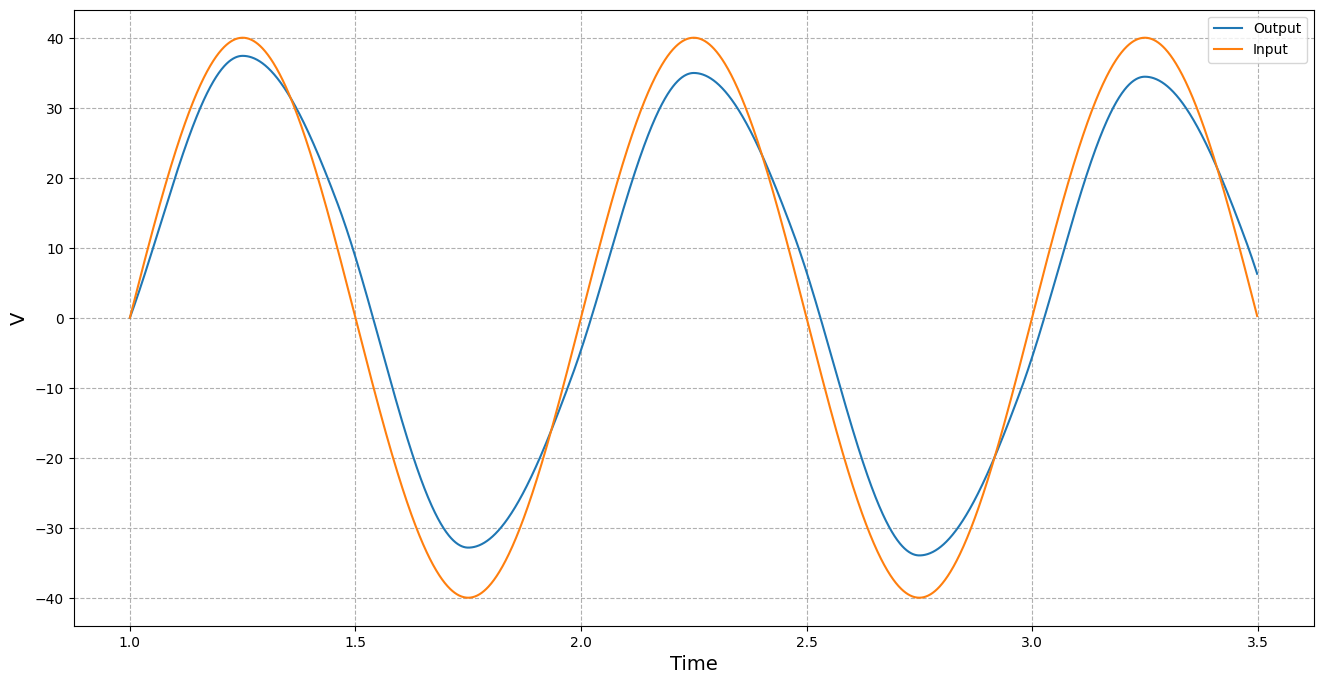

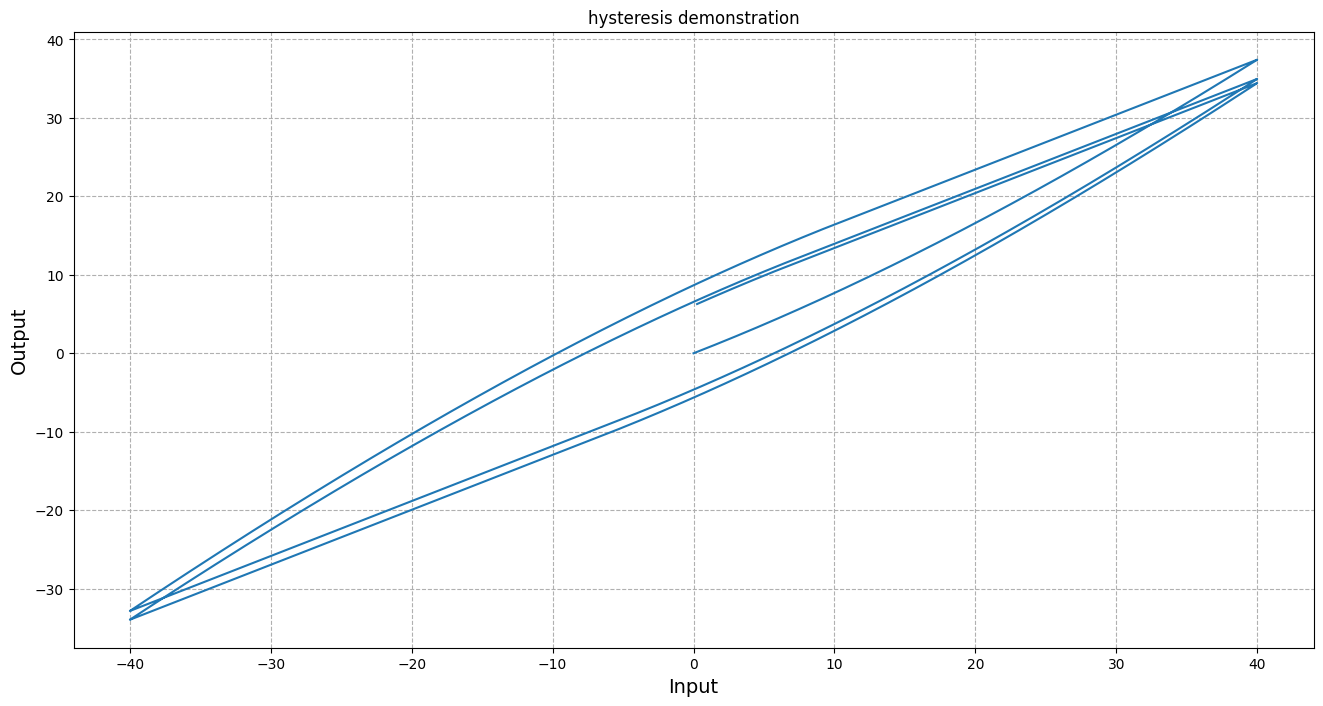

In [8]:
split = 2500
fontsize = 14
# time = data[1][:split]
plt.figure(figsize=(16, 8))
plt.plot(t[:split], y_test[:split], label='Output')
plt.plot(t[:split], u_test[:split], label='Input')
plt.grid(linestyle="--")
plt.xlabel("Time", fontsize=fontsize)
plt.ylabel("V", fontsize=fontsize)
plt.legend()
plt.show()


plt.figure(figsize=(16, 8))
plt.title("hysteresis demonstration")
# plt.plot(u_train[:split], y_train[:split])
plt.plot(u_test[:split], y_test[:split])
plt.grid(linestyle="--")
plt.xlabel("Input", fontsize=fontsize)
plt.ylabel("Output", fontsize=fontsize)
plt.show()

In [ ]:

# REMEMBER: Verify the set of subtration and sign functions in class Element (base.py)
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            validation=(u_test, y_test),
            nDelays=[1, 2, 3, 4, 5],
            generations=250,
            populationSize=250,
            evaluationMode="RMSE",
            k=500,
            froe_mode=True,
            evaluationType='MShooting',
            evaluationTypeTest="FreeRun",
            nTerms=10,
            maxHeight=5,
            mutationRate=0.2,
            crossoverRate=0.8,
            pruning_probability=0.5,
            pruning_tolerance= 1e-5, 
            elitePercentage=10,
            filename = "mggp_models_hysteresis/mggp_0.pkl",
            mode="MIMO",
            operators=['mul', 'sign', 'subtraction']
            )

mggp.run()

System Mode: SISO. N° Inputs: 1. N° Outputs: 1
Input Samples: 100000. Output Samples: 100000



Evaluating Initial Population:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluating Initial Population:   6%|▌         | 15/250 [00:03<00:47,  4.99it/s]

## Load and Evaluate Model

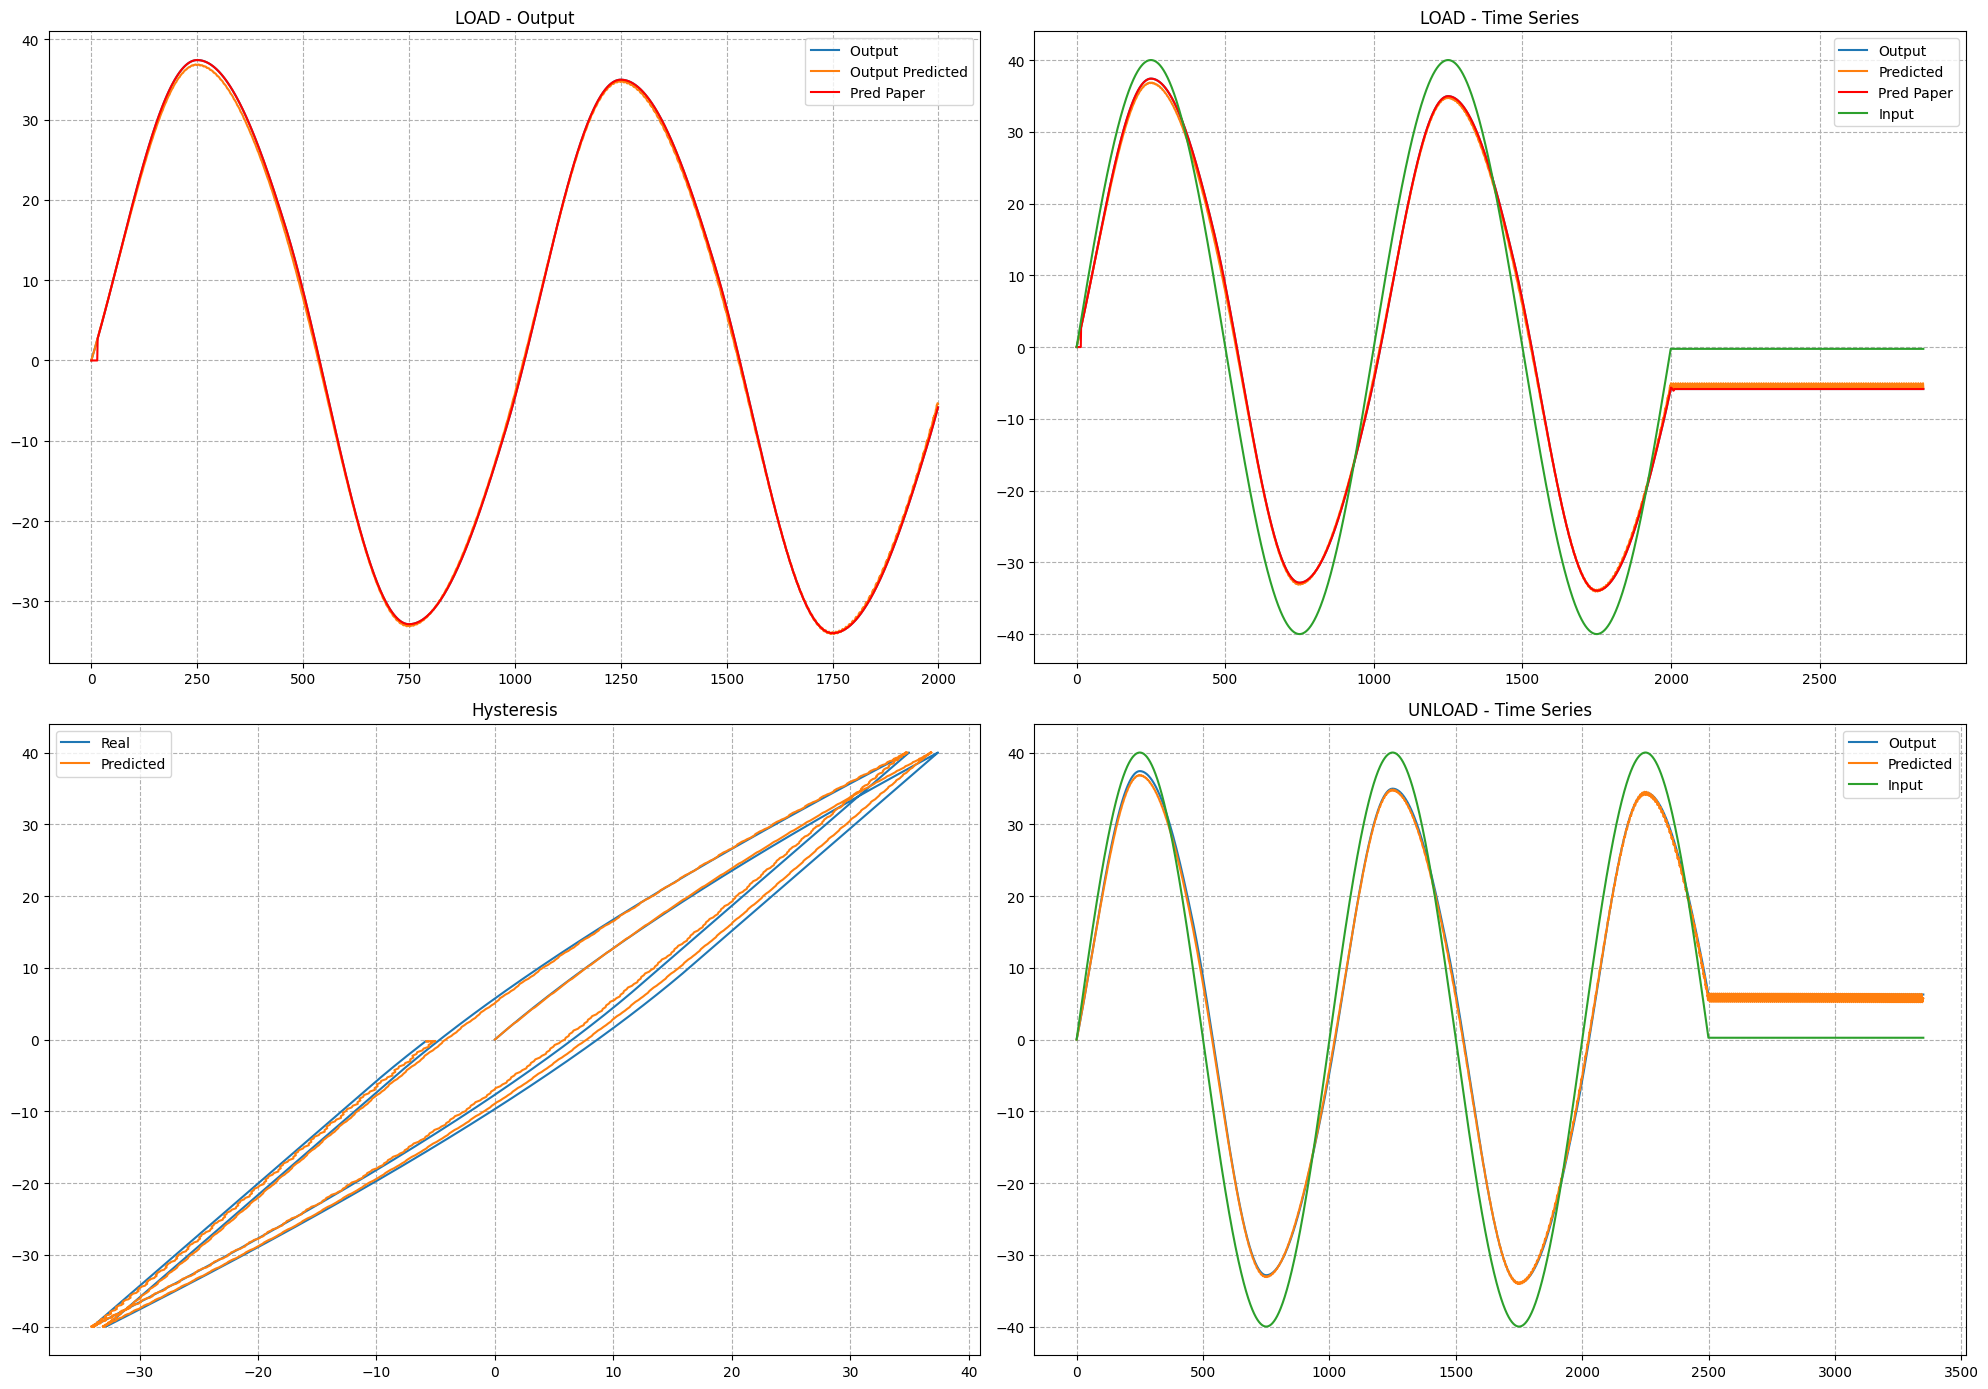

In [ ]:
# Filter requirements.
fs = 1000       # sample rate, Hz
cutoff = 1     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
nyq = 0.5 * fs  # Nyquist Frequency
order = 5      # sin wave can be approx represented as quadratic

t = np.arange(0,101,1/fs)
seed = 93862723
np.random.seed(seed)
dataX = np.random.normal(0, 450, size=(len(t)))
dataX[0:1000] = 0
dataX[-1000:] = 0
u = butter_lowpass_filter(dataX, cutoff, fs, order)
u = u.reshape(-1)
udot = np.diff(u)/np.diff(t)
udot = udot[999:]
u_train = u[1000:]
t = t[1000:]

y_train = simulate(u_train, udot)

u_test = 40*np.sin(2*np.pi*t)
udot = np.diff(u_test)/np.diff(t)
y_test = simulate(u_test, udot)

u_train = np.array([u_train]).T
y_train = np.array([y_train]).T
u_test = np.array([u_test]).T
y_test = np.array([y_test]).T

# ===================== LOAD =====================
split = 2000

u_test_load = u_test[:split]
y_test_load = y_test[:split]

model_filename = "mggp_models_hysteresis\\mggp_0.pkl"

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load, 
    y_val=y_test_load, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load) - len(mggp_yd)
y_true_complete = y_test_load[mggp_initial_conditions:]
ypred_mcase1 = mcase1(u_test_load, y_test_load)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]

plt.figure(figsize=(20, 14))

# --- LOAD: saída ---
plt.subplot(2, 2, 1)
plt.plot(y_true_complete, label='Output ')
plt.plot(mggp_pred_complete, label='Output Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.title("LOAD - Output")
plt.grid(linestyle='--')
plt.legend()

# Extensão (load)
y_test_extend = np.repeat(y_test_load[-1], 850).reshape(-1, 1)
y_test_load_ext = np.concatenate([y_test_load, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_load[-1], 850).reshape(-1, 1)
u_test_load_ext = np.concatenate([u_test_load, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load_ext, 
    y_val=y_test_load_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load_ext) - len(mggp_yd)
y_true_complete = y_test_load_ext[mggp_initial_conditions:]
input_complete = u_test_load_ext[mggp_initial_conditions:]
ypred_mcase1 = mcase1(u_test_load_ext, y_test_load_ext)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]


# --- LOAD: histerese ---
plt.subplot(2, 2, 2)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.plot(input_complete, label='Input')
plt.title("LOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_true_complete, input_complete, label='Real')
plt.plot(mggp_pred_complete, input_complete, label='Predicted')
plt.title("Hysteresis")
plt.grid(linestyle='--')
plt.legend()


# ===================== UNLOAD =====================
split = 2500

u_test_unload = u_test[:split]
y_test_unload = y_test[:split]

# Extensão (unload)
y_test_extend = np.repeat(y_test_unload[-1], 850).reshape(-1, 1)
y_test_unload_ext = np.concatenate([y_test_unload, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_unload[-1], 850).reshape(-1, 1)
u_test_unload_ext = np.concatenate([u_test_unload, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_unload_ext, 
    y_val=y_test_unload_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_unload_ext) - len(mggp_yd)
y_true_complete = y_test_unload_ext[mggp_initial_conditions:]
input_complete = u_test_unload_ext[mggp_initial_conditions:]

min_length = min(len(y_true_complete), len(mggp_pred))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]

# --- UNLOAD: time series ---
plt.subplot(2, 2, 4)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(input_complete, label='Input')
plt.title("UNLOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()


# Train Piezoelectric Micromanipulator Benchmark

In [7]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)
data

,1,2,3,4,5,6
0,0.00000,39.882983,6.646888,4.455033,21.63725,6.646888
1,0.00005,42.248096,6.840738,4.648882,21.63730,6.840738
2,0.00010,44.872607,6.993324,4.801468,21.63735,6.993324
3,0.00015,46.612109,7.103292,4.911436,21.63740,7.103292
4,0.00020,48.061694,7.169665,4.977810,21.63745,7.169665
...,...,...,...,...,...,...
199996,9.99980,28.545703,5.498415,3.306559,31.63705,5.498415
199997,9.99985,31.566943,5.836699,3.644843,31.63710,5.836699
199998,9.99990,34.527148,6.142631,3.950775,31.63715,6.142631
199999,9.99995,37.197437,6.413495,4.221640,31.63720,6.413495


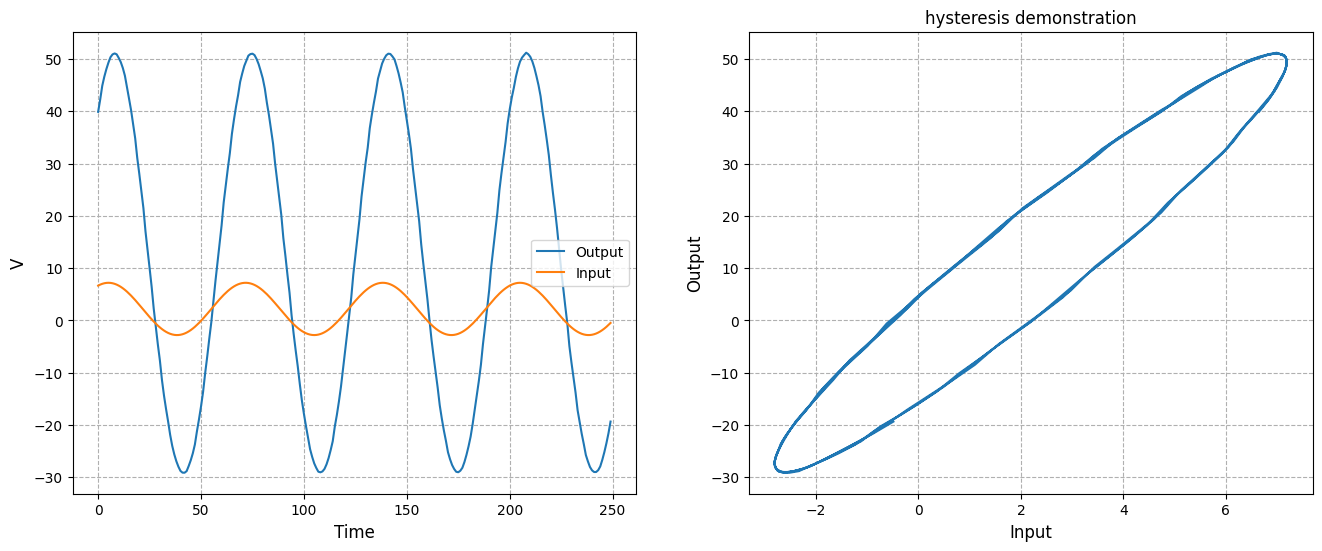

In [7]:
split = 250
fontsize = 12
sinal_in = 3
sinal_out = 2
time = data[1][:split]
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(data[sinal_out][:split], label='Output')
plt.plot(data[sinal_in][:split], label='Input')
plt.grid(linestyle="--")
plt.xlabel("Time", fontsize=fontsize)
plt.ylabel("V", fontsize=fontsize)
plt.legend()

plt.subplot(1, 2, 2)
# plt.figure(figsize=(16, 8))
plt.title("hysteresis demonstration")
plt.plot(data[sinal_in][:split], data[sinal_out][:split])
plt.grid(linestyle="--")
plt.xlabel("Input", fontsize=fontsize)
plt.ylabel("Output", fontsize=fontsize)
plt.show()

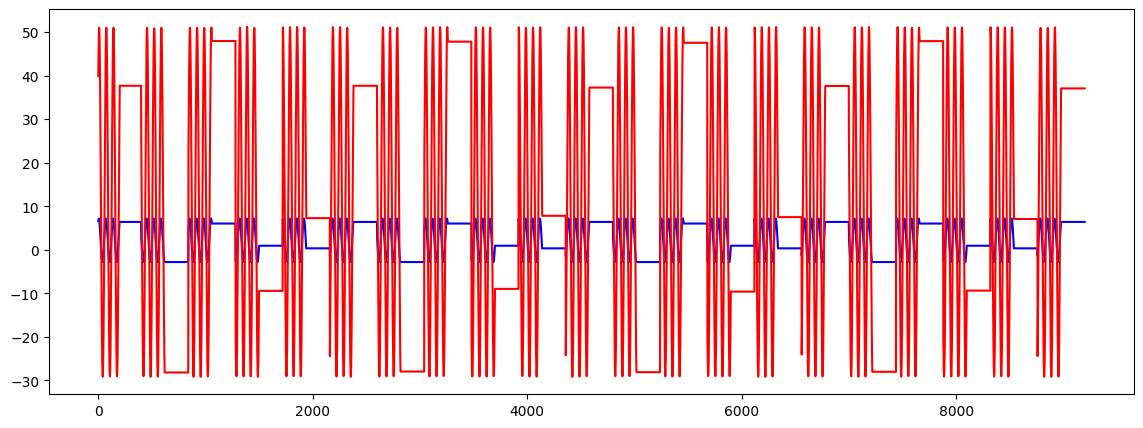

In [7]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 200
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split].values.reshape(-1, 1)
input = data[sinal_in][:split].values.reshape(-1, 1)


output_extend = np.repeat(output[-1], split).reshape(-1, 1)
input_extend = np.repeat(input[-1], split).reshape(-1, 1)

output = np.concatenate([output, output_extend], axis=0)
input = np.concatenate([input, input_extend], axis=0)
split += 20
for i in range(1, 40, 2):
    
    output_step = data[sinal_out][split*i:split*(i+1)].values.reshape(-1, 1)
    input_step = data[sinal_in][split*i:split*(i+1)].values.reshape(-1, 1)

    output_extend = np.repeat(output_step[-1], split).reshape(-1, 1)
    input_extend = np.repeat(input_step[-1], split).reshape(-1, 1)

    output = np.concatenate([output, output_step, output_extend], axis=0)
    input = np.concatenate([input, input_step, input_extend], axis=0)

u_train = input
y_train = output
plt.figure(figsize=(14, 5))
plt.plot(input, color='b')
plt.plot(output, color='r')
plt.show()

# shottings = 10
# split = output.shape[0]//shottings
# for i in range(shottings):
    
#     output_step = output[split*i:split*(i+1)]
#     input_step = input[split*i:split*(i+1)]

#     plt.figure(figsize=(14, 5))
#     plt.plot(input_step, color='b')
#     plt.plot(output_step, color='r')
#     plt.show()

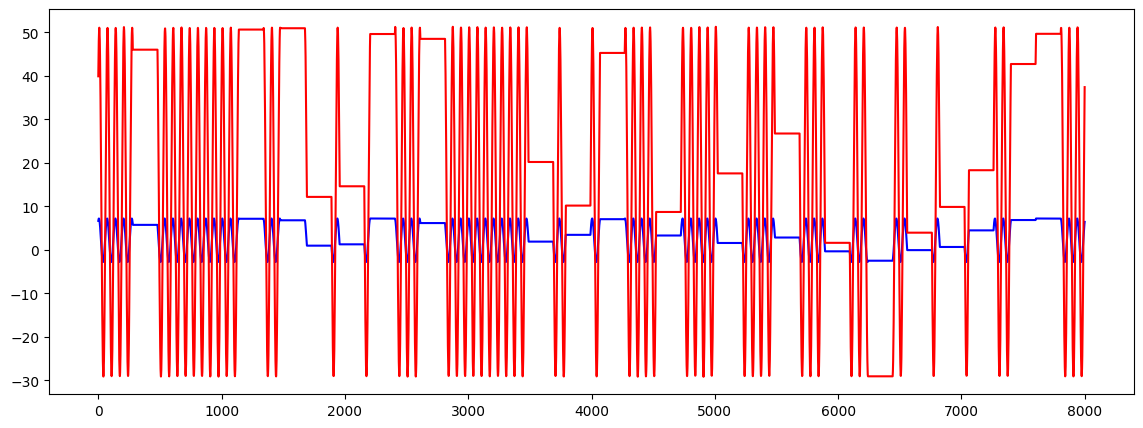

In [ ]:
split = 4000
u_train = data[3][:split].values.reshape(-1, 1)
y_train = data[2][:split].values.reshape(-1, 1)

n_const =20        # quantidade de trechos constantes
len_const = 200     # tamanho de cada trecho
seed = 463
u_train = insert_constant_segments(u_train, n_const, len_const, seed=seed)
y_train = insert_constant_segments(y_train, n_const, len_const, seed=seed)
plt.figure(figsize=(14, 5))
plt.plot(u_train, color='b')
plt.plot(y_train, color='r')
plt.show()

# como a gente tá usando multi shotting,por exemplo, dos 100 shotings seria interessante que 50 fosse uma predição constante e 50 fosse predição oscilatória.

In [8]:
# data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
# data.drop(0, axis=1, inplace=True)
# split = 4000
# u_train = data[3][:split].values.reshape(-1, 1)
# y_train = data[2][:split].values.reshape(-1, 1)

# n_const = 20        # quantidade de trechos constantes
# len_const = 200     # tamanho de cada trecho
# seed = 463
# u_train = insert_constant_segments(u_train, n_const, len_const, seed=seed)
# y_train = insert_constant_segments(y_train, n_const, len_const, seed=seed)
# REMEMBER: Verify the set of subtration and sign functions in class Element (base.py)
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            validation=(u_train, y_train),
            nDelays=1,
            generations=400,
            populationSize=500,
            evaluationMode="MSE",
            k=100,
            froe_mode=True,
            evaluationType='MShooting',
            evaluationTypeTest="FreeRun",
            nTerms=15,
            maxHeight=3,
            mutationRate=0.2,
            crossoverRate=0.8,
            pruning_probability=0.5,
            pruning_tolerance= 1e-4, 
            elitePercentage=10,
            filename = "mggp_models_hysteresis_piezoeletric/mggp_18.pkl",
            mode="MIMO",
            operators=['mul', 'sign', 'subtraction']
            )

mggp.run()

System Mode: SISO. N° Inputs: 1. N° Outputs: 1
Input Samples: 9200. Output Samples: 9200



Evaluating Initial Population:  21%|██        | 104/500 [00:02<00:08, 44.72it/s]


KeyboardInterrupt: 

## Load and Evaluate Model

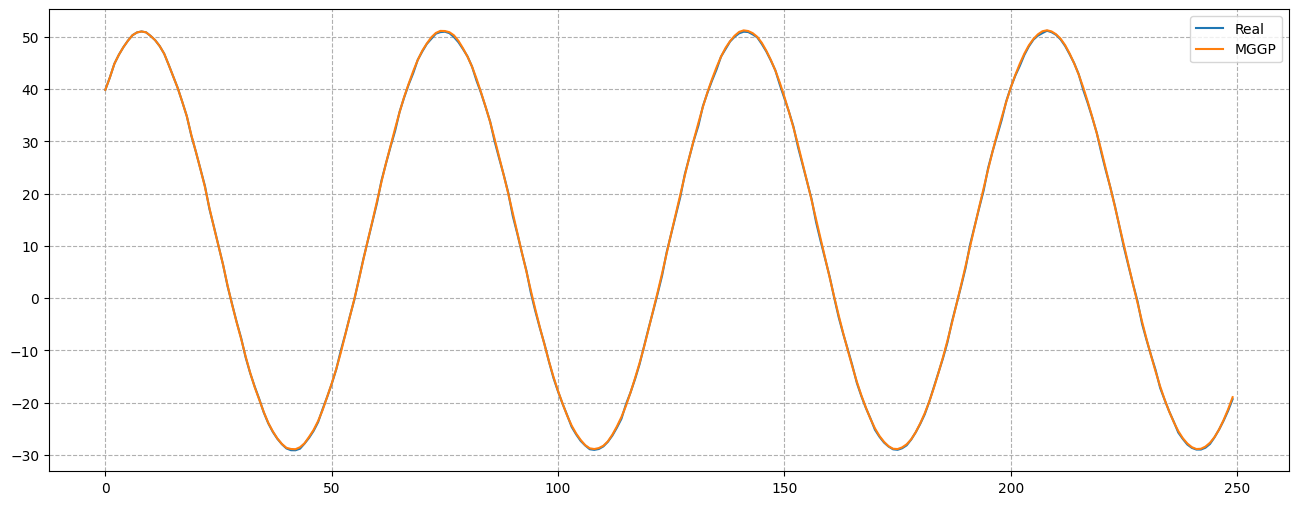

In [26]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 250
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split]
input = data[sinal_in][:split]

input = input.values.reshape(-1, 1)
output = output.values.reshape(-1, 1)

model_filename = "mggp_models_hysteresis_piezoeletric\mggp_0.pkl"
# model_filename = "mggp_models_hysteresis/mggp_0.pkl"
mggp_pred, mggp_yd = mggp_predict(X_val=input, 
                                  y_val=output, 
                                  save_model=model_filename)

            
mggp_initial_conditions = len(output) - len(mggp_yd)
y_true_complete = output[mggp_initial_conditions:]
                     
min_length = min(len(y_true_complete), len(mggp_pred))
y_true_complete = y_true_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]

plt.figure(figsize=(16, 6))
plt.plot(y_true_complete, label='Real')
plt.plot(mggp_pred_complete, label='MGGP')
plt.grid(linestyle='--')
plt.legend()
plt.show()

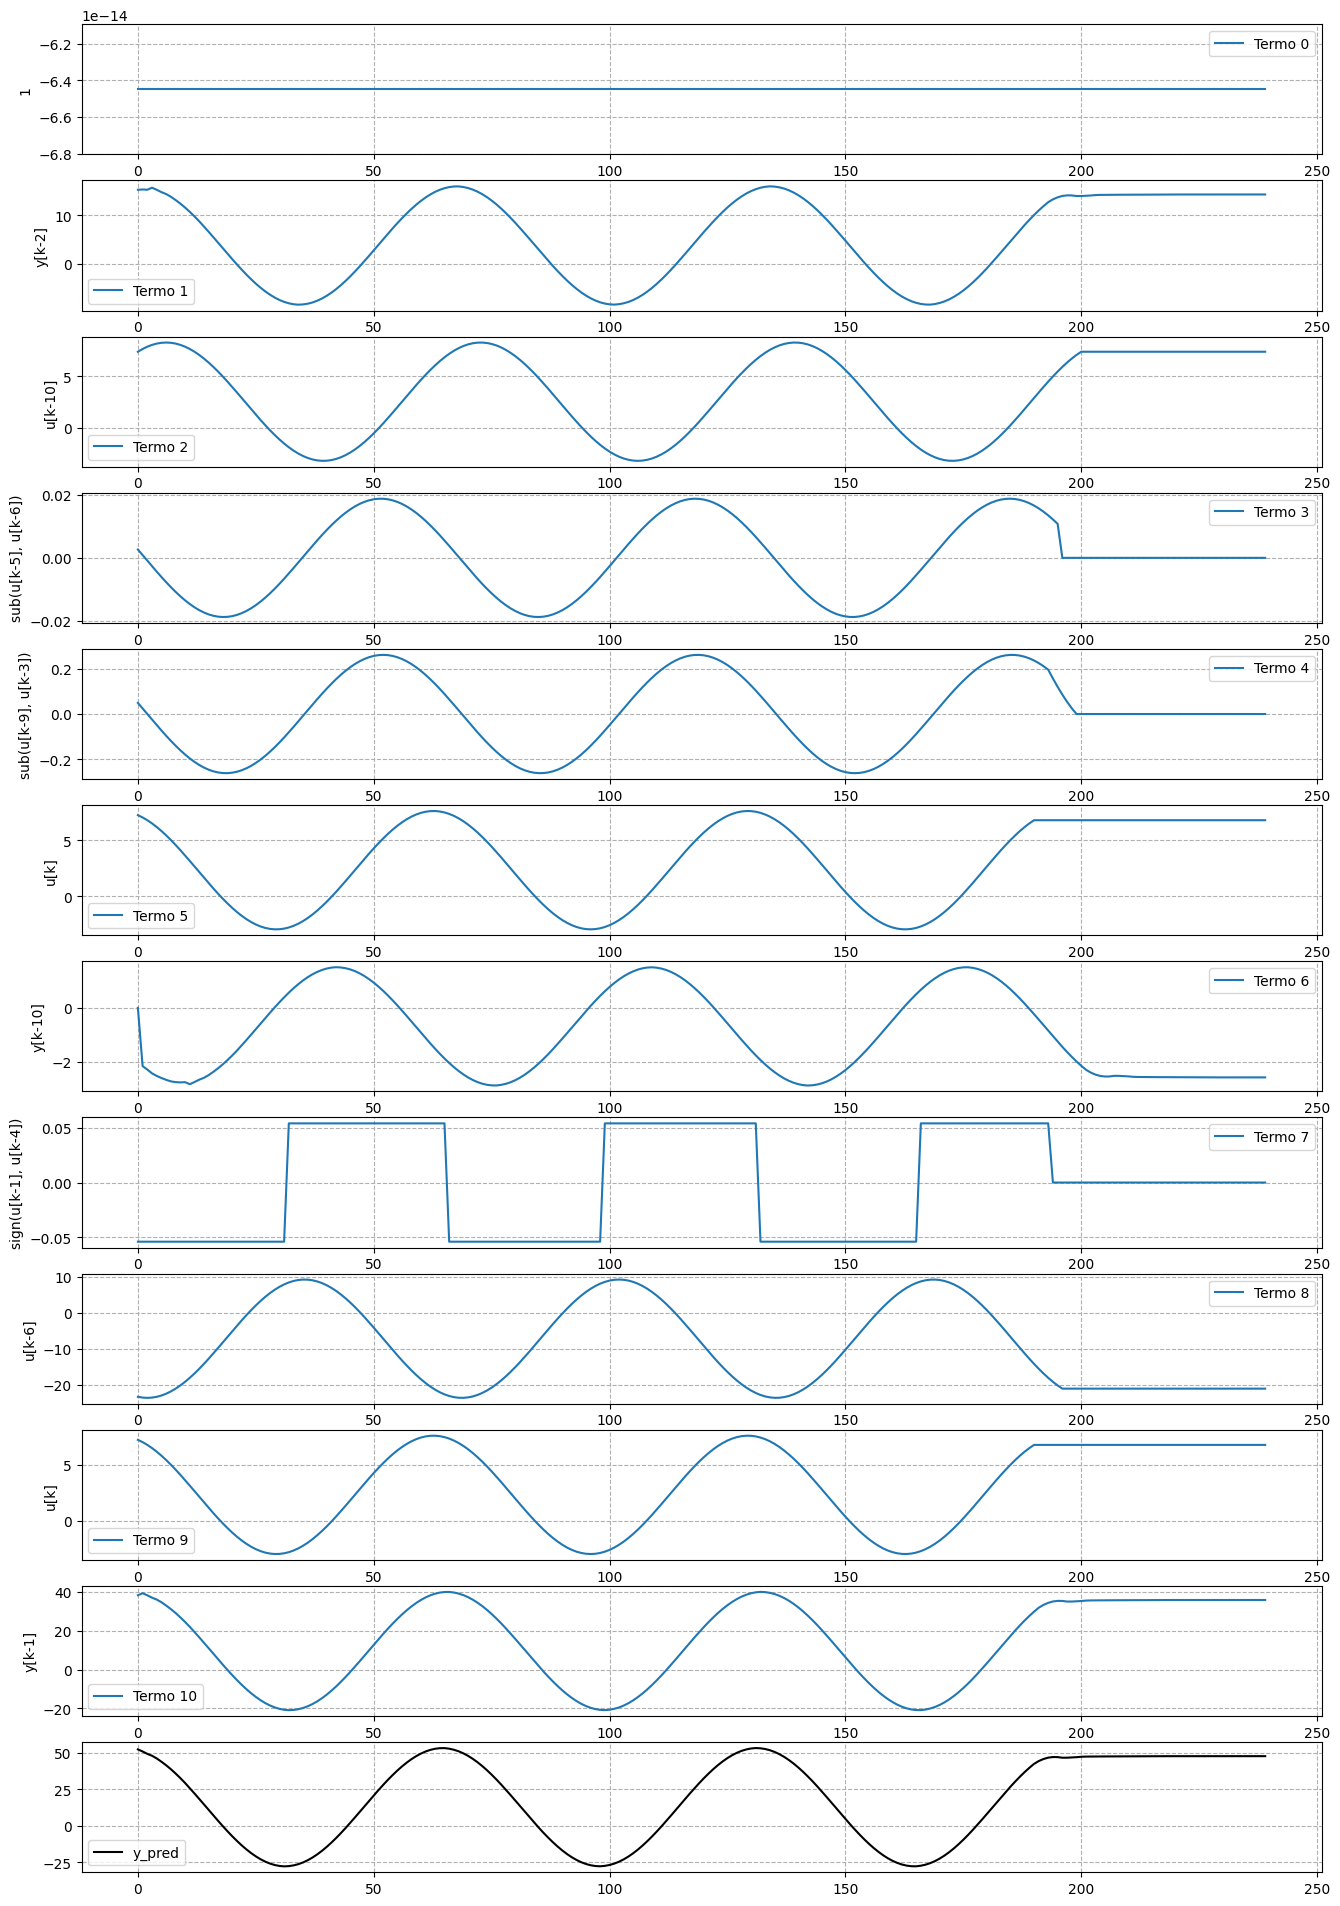

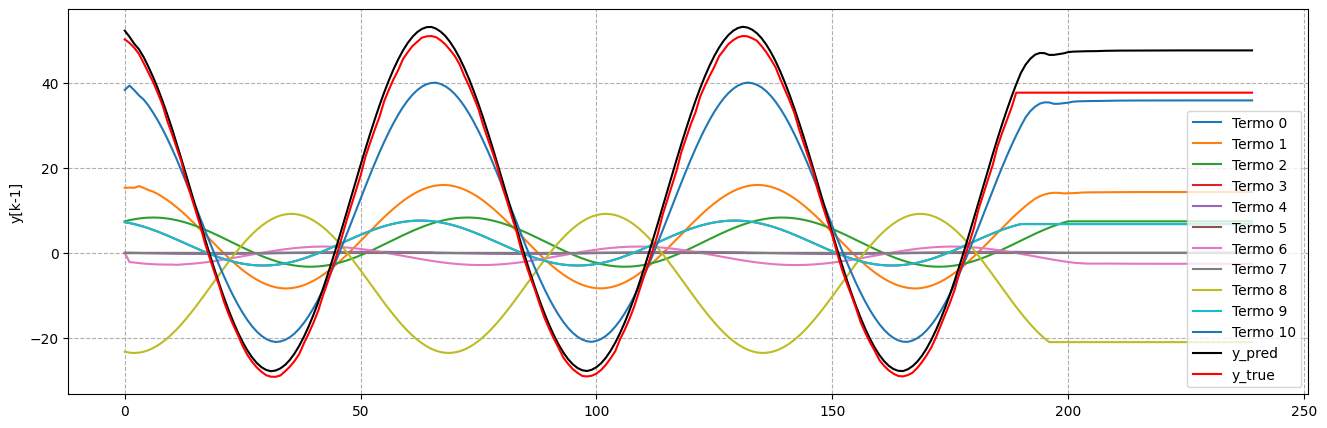

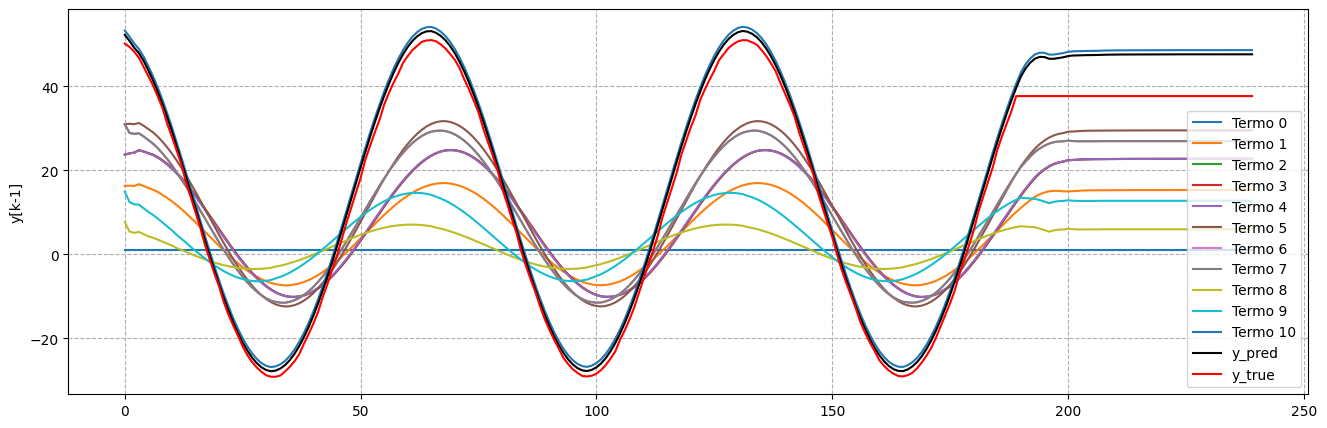

In [9]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 200
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split]
input = data[sinal_in][:split]

input = input.values.reshape(-1, 1)
output = output.values.reshape(-1, 1)

output_extend = np.repeat(output[-1], 50).reshape(-1, 1)
output = np.concatenate([output, output_extend], axis=0)

input_extend = np.repeat(input[-1], 50).reshape(-1, 1)
input = np.concatenate([input, input_extend], axis=0)


y_pred, terms = mcase_free_run_terms(input, output)
term_strings = [
    "1",  # theta[0] (bias)
    "y[k-2]",
    "u[k-10]",
    "sub(u[k-5], u[k-6])",
    "sub(u[k-9], u[k-3])",
    "u[k]",
    "y[k-10]",
    "sign(u[k-1], u[k-4])",
    "u[k-6]",
    "u[k]",
    "y[k-1]"
]


plt.figure(figsize=(16, 24))
for i in range(terms.shape[0]):
    plt.subplot(12, 1, i+1)
    plt.plot(terms[i], label=f"Termo {i}")
    plt.ylabel(term_strings[i])
    plt.grid(linestyle='--')
    plt.legend()

plt.subplot(12, 1, 12)
plt.plot(y_pred, label='y_pred', color='k')
plt.grid(linestyle='--')
plt.legend()
plt.show()


plt.figure(figsize=(16, 5))
for i in range(terms.shape[0]):
    # plt.subplot(12, 1, i+1)
    plt.plot(terms[i], label=f"Termo {i}")
    plt.ylabel(term_strings[i])
    plt.grid(linestyle='--')
    plt.legend()

# plt.subplot(12, 1, 12)
plt.plot(y_pred, label='y_pred', color='k')
plt.plot(output[10:], label='y_true', color='r')
plt.grid(linestyle='--')
plt.legend()
plt.show()

all_terms = np.ones(terms[i].shape)
plt.figure(figsize=(16, 5))
for i in range(terms.shape[0]):
    # plt.subplot(12, 1, i+1)
    all_terms += terms[i]
    plt.plot(all_terms, label=f"Termo {i}")
    plt.ylabel(term_strings[i])
    plt.grid(linestyle='--')
    plt.legend()

# plt.subplot(12, 1, 12)
plt.plot(y_pred, label='y_pred', color='k')
plt.plot(output[10:], label='y_true', color='r')
plt.grid(linestyle='--')
plt.legend()
plt.show()


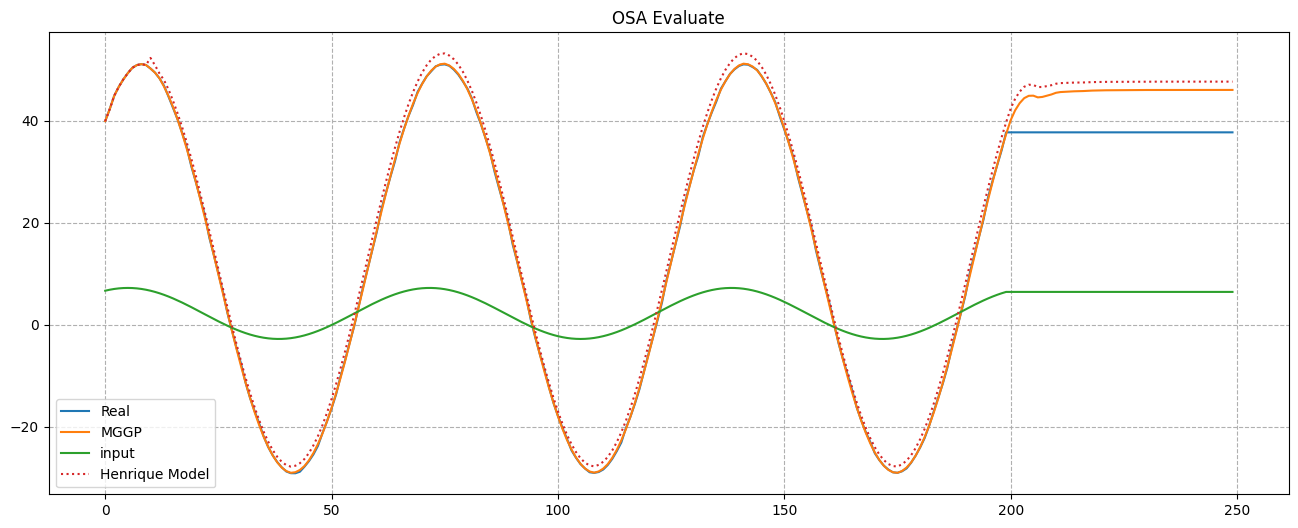

In [20]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 200
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split]
input = data[sinal_in][:split]

input = input.values.reshape(-1, 1)
output = output.values.reshape(-1, 1)

output_extend = np.repeat(output[-1], 50).reshape(-1, 1)
output = np.concatenate([output, output_extend], axis=0)

input_extend = np.repeat(input[-1], 50).reshape(-1, 1)
input = np.concatenate([input, input_extend], axis=0)

model_filename = "mggp_models_hysteresis_piezoeletric\mggp_17.pkl"
# model_filename = "mggp_models/hysteresis_model.pkl"
# model_filename = "mggp_models_hysteresis/mggp_0.pkl"
# model_filename = "mggp_models/hysteresis_model.pkl"
mggp_pred, mggp_yd = mggp_predict(X_val=input, 
                                  y_val=output, 
                                #   evaluationTypeTest="OSA",
                                  save_model=model_filename)


ypred_mcase = mcase(input, output)
mggp_initial_conditions = len(output) - len(mggp_yd)
y_true_complete = output[mggp_initial_conditions:]
input_complete = input[mggp_initial_conditions:]
mcase2_complete = ypred_mcase[mggp_initial_conditions:]

min_length = min(len(y_true_complete), len(mggp_pred))

y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]

plt.figure(figsize=(16, 6))
plt.title("OSA Evaluate")
plt.plot(y_true_complete, label='Real')
plt.plot(mggp_pred_complete, label='MGGP')
plt.plot(input_complete, label='input')
plt.plot(mcase2_complete, label='Henrique Model', linestyle=':')
plt.grid(linestyle='--')
plt.legend()
plt.show()

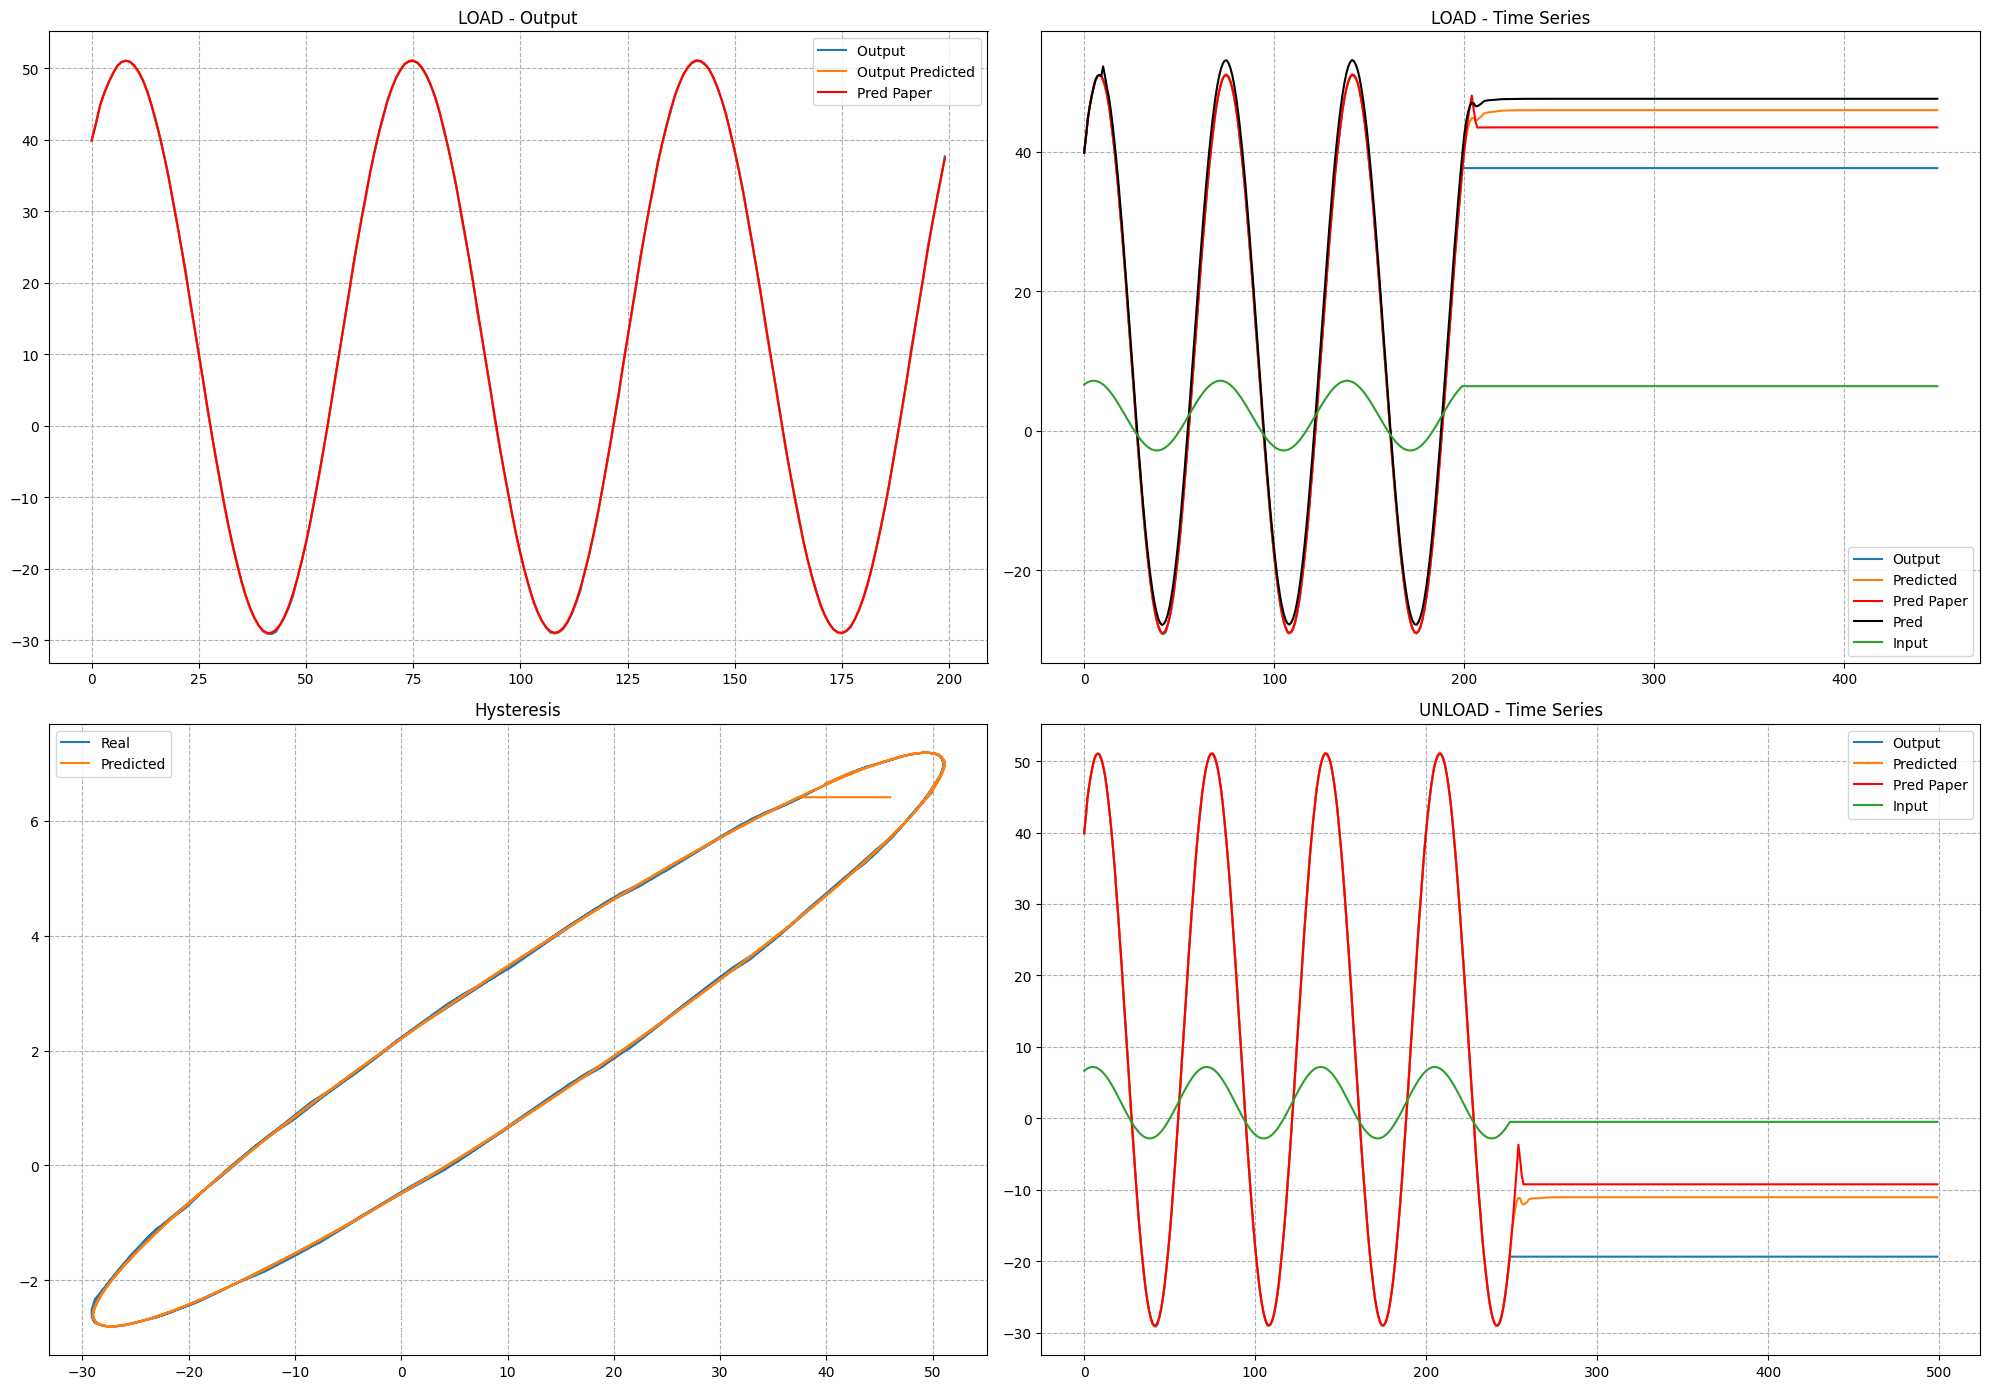

In [42]:
# ===================== LOAD =====================
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

sinal_in = 3
sinal_out = 2
time = data[1]

output = data[sinal_out]
input = data[sinal_in]

u_test = input.values.reshape(-1, 1)
y_test = output.values.reshape(-1, 1)

split = 200

u_test_load = u_test[:split]
y_test_load = y_test[:split]

model_filename = "mggp_models_hysteresis_piezoeletric\\mggp_17.pkl"

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load, 
    y_val=y_test_load, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load) - len(mggp_yd)
y_true_complete = y_test_load[mggp_initial_conditions:]
ypred_mcase1 = mcase2(u_test_load, y_test_load)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]

plt.figure(figsize=(20, 14))

# --- LOAD: saída ---
plt.subplot(2, 2, 1)
plt.plot(y_true_complete, label='Output ')
plt.plot(mggp_pred_complete, label='Output Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.title("LOAD - Output")
plt.grid(linestyle='--')
plt.legend()

# Extensão (load)
y_test_extend = np.repeat(y_test_load[-1], 250).reshape(-1, 1)
y_test_load_ext = np.concatenate([y_test_load, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_load[-1], 250).reshape(-1, 1)
u_test_load_ext = np.concatenate([u_test_load, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load_ext, 
    y_val=y_test_load_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load_ext) - len(mggp_yd)
y_true_complete = y_test_load_ext[mggp_initial_conditions:]
input_complete = u_test_load_ext[mggp_initial_conditions:]
ypred_mcase1 = mcase2(u_test_load_ext, y_test_load_ext)
ypred_mcase = mcase(u_test_load_ext, y_test_load_ext)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1), len(ypred_mcase))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]
ypred_mcase_complete = ypred_mcase[:min_length]

# --- LOAD: histerese ---
plt.subplot(2, 2, 2)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.plot(ypred_mcase_complete, label='Pred', color='k')
plt.plot(input_complete, label='Input')
plt.title("LOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_true_complete, input_complete, label='Real')
plt.plot(mggp_pred_complete, input_complete, label='Predicted')
plt.title("Hysteresis")
plt.grid(linestyle='--')
plt.legend()


# ===================== UNLOAD =====================
split = 250

u_test_unload = u_test[:split]
y_test_unload = y_test[:split]

# Extensão (unload)
y_test_extend = np.repeat(y_test_unload[-1], 250).reshape(-1, 1)
y_test_unload_ext = np.concatenate([y_test_unload, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_unload[-1], 250).reshape(-1, 1)
u_test_unload_ext = np.concatenate([u_test_unload, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_unload_ext, 
    y_val=y_test_unload_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_unload_ext) - len(mggp_yd)
y_true_complete = y_test_unload_ext[mggp_initial_conditions:]
input_complete = u_test_unload_ext[mggp_initial_conditions:]
ypred_mcase1 = mcase2(u_test_unload_ext, y_test_unload_ext)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]

# --- UNLOAD: time series ---
plt.subplot(2, 2, 4)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.plot(input_complete, label='Input')
plt.title("UNLOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()


# Load MGGP Model

In [ ]:
folder = "Job1_2023_07_28_16_41_10_Mix"
path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_extraidas_35_25.csv"
u_train, y_train, _, _ = load_data(path, 3, folder)

save_model = "mggp_models_hysteresis_piezoeletric/mggp_17.pkl"
# save_model = "mggp_models/hysteresis_model.pkl"
# save_model = "mggp_models_hysteresis/mggp_1.pkl"
mggp = MGGP(inputs=u_train,
                    outputs=y_train,
                    filename=save_model, 
                    operators=['mul', 'sign', 'subtraction']
                    # kwargs={'operators': ['mul', 'subtraction', 'sign']}
                    )

loaded_model = mggp.load_model()

# print(mggp.simplify_model(loaded_model))
print(loaded_model)

1
q2(y1)
q5(q2(q1(q1(q1(u1)))))
q4(subtraction(q1(u1), q2(u1)))
q3(subtraction(q5(q4(u1)), q1(q2(u1))))
u1
q2(q4(q4(y1)))
sign(q1(u1), q2(q1(q1(u1))))
q5(q1(u1))
u1
y1



In [19]:
soma = 0
for i in [2, 5, 8, 9]: # termos lineares input
# for i in [1, 6, 10]: # linear outputs
# for i in [3, 4, 7]: # phi outputs
    soma += loaded_model.theta[i][0]
soma

4.596323321948148e-14

In [14]:
for i in range(len(loaded_model.theta)):
    print(f'{i} - {loaded_model.theta[i][0]}')

0 - -6.449701883681769e-14
1 - 0.300742221603808
2 - 1.157059550460019
3 - 0.03974769250889043
4 - -0.09372108147028588
5 - 1.0571898587117923
6 - -0.05383488830604312
7 - 0.05397338896144662
8 - -3.271439267907053
9 - 1.0571898587352877
10 - 0.7530926667022311


In [ ]:
1, 2, 4, 5, 6, 

In [9]:
soma = loaded_model.theta[0][0]
# soma = 0
for i in [1, 2, 4, 5, 6]:
    soma += loaded_model.theta[i][0]

soma

2.44050622390821